In [1]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
import re
from rasterio.plot import plotting_extent
from datetime import datetime
from scipy.stats import linregress
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib
import seaborn as sns
from metloom.pointdata import SnotelPointData
from glob import glob

sys.path.append('../scripts')
from model_comparison_functions import (
    process_all_dates, get_raw_data, get_raster_pixel_value, x_y_snotel
)

# Root directory containing the per-date "dates/<YYYYMMDD>/" folders produced by Model_prep.py
base_dir = "/Users/rdcrlrka/Research/SIRO/MCSModeling/SIRO_P1/dates"

# Where to save figures
fig_dir = "/Users/rdcrlrka/Research/SIRO/MCSModeling/figures"
os.makedirs(fig_dir, exist_ok=True)

# Plot settings
plt.rcParams.update({'font.size': 12, "font.sans-serif": "Verdana"})

## Define colormaps

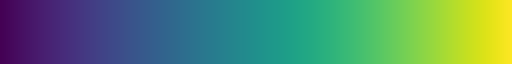

In [2]:
# Snow depth
sd_cmap = plt.cm.viridis
sd_cmap

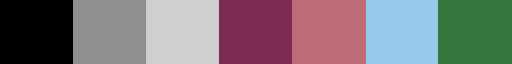

In [3]:
# Datasets
ds_colors_dict = {
    "SPIReS":       "#000000",
    "LiDAR":        "#8E8E8E",
    "LiDAR-2000":   "#CECECE",
    "HMS-EB":       "#7D2B54",
    "HMS-TI":       "#BF6B78",
    "iSnobal":      "#97CAEA",
    "SnowModel":    "#37753B"
}
ds_colors = list(ds_colors_dict.values())
ds_cmap = matplotlib.colors.ListedColormap(ds_colors)
ds_cmap

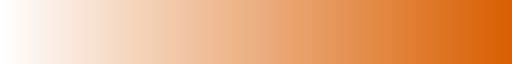

In [4]:
base_run_color = '#1b9e77'
assim_run_color = '#d95f02'

base_run_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name='baseline_cmap', colors=['w', base_run_color])
assim_run_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name='baseline_cmap', colors=['w', assim_run_color])

assim_run_cmap

# Example snow depths map view + basin outline

In [5]:
# Load required input files
example_date = "20230405"

task1 = process_all_dates(base_dir, 1)

mcs_shp = gpd.read_file(os.path.join(base_dir, example_date, "MCS_outline", "MCS_outline.shp"))
basin_shp = gpd.read_file(os.path.join(base_dir, example_date, "MCS_outline", "basin_outline.shp"))

basin_rasters = task1[example_date]['basin_clip']
raster_list = {
    "HMS-EB": basin_rasters["HMS-EB"],
    "HMS-TI": basin_rasters["HMS-TI"],
    "SnowModel": basin_rasters["SnowModel"],
    "iSnobal": basin_rasters["iSnobal"],
}

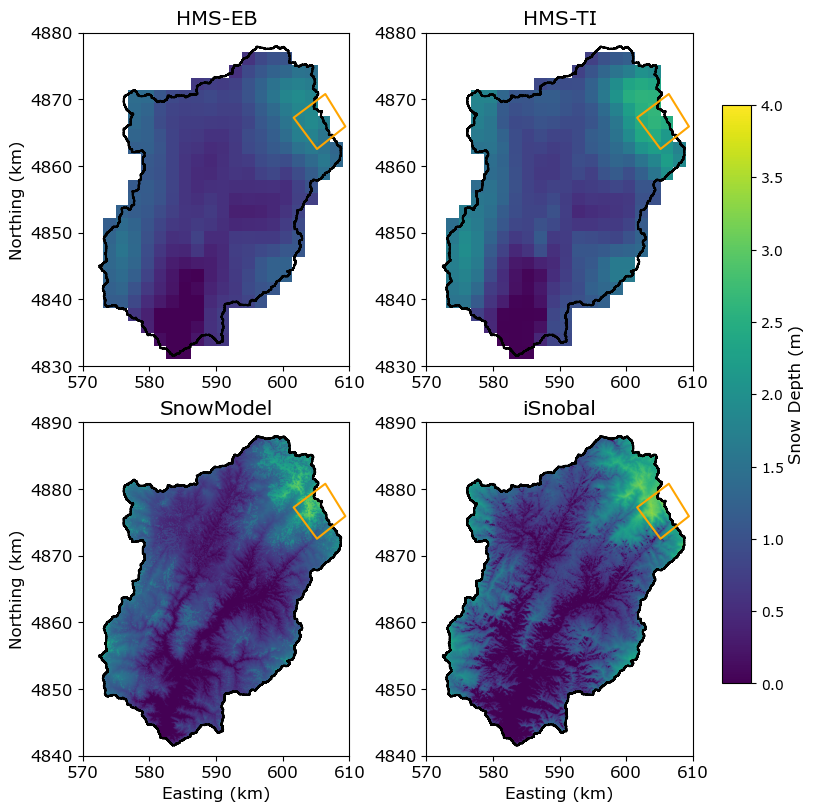

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/map_view_20230405_v2.png


In [6]:
# Make the figure and save
fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
axes = axes.flatten()

for i, (model, raster_path) in enumerate(raster_list.items()):
    with rxr.open_rasterio(raster_path, mask_and_scale=True).squeeze() as raster:
        im = axes[i].imshow(
            raster.data, cmap=sd_cmap,  vmin=0, vmax=4.0,
            extent=(min(raster.x), max(raster.x), min(raster.y), max(raster.y)),
            )

    basin_shp.plot(ax=axes[i], facecolor="none", edgecolor="k", linewidth=1.5)
    mcs_shp.plot(ax=axes[i], facecolor="none", edgecolor="orange", linewidth=1.5)

    axes[i].set_title(model)
    axes[i].grid(False)
    axes[i].set_aspect("equal")

# convert axes units to km
for ax in axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels([int(x/1e3) for x in axes[0].get_xticks()])
    ax.set_xlim(570e3, 610e3)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([int(y/1e3) for y in axes[0].get_yticks()])
    ax.set_ylim(4830e3, 4880e3)
for ax in [axes[0], axes[2]]:
    ax.set_ylabel("Northing (km)")
for ax in [axes[2], axes[3]]:
    ax.set_xlabel("Easting (km)")

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Snow Depth (m)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.show()

fig_file = os.path.join(fig_dir, f"map_view_{example_date}_v2.png")
fig.savefig(fig_file, dpi=300, bbox_inches="tight")
print("Figure saved to:", fig_file)

# Boxplots of snow depth distributions on each LiDAR date

In [7]:
# Load required input files
task1 = process_all_dates(base_dir, 1)

dfs = []
for date, contents in task1.items():
    if 'lidar_clip' not in contents:
        continue
    for model, raster_path in contents['lidar_clip'].items():
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            data_masked = np.ma.array(data, mask=(data == -9999))
            flattened = data_masked.compressed()
            flattened = flattened[flattened < 5]

        dfs.append(pd.DataFrame({
            "Date": date,
            "Model": model,
            "Snow Depth": flattened,
        }))

lidar_domain = pd.concat(dfs, ignore_index=True)

/var/folders/46/lc6lgy656cq4n776s7js9r880000gr/T/ipykernel_6967/3590980526.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


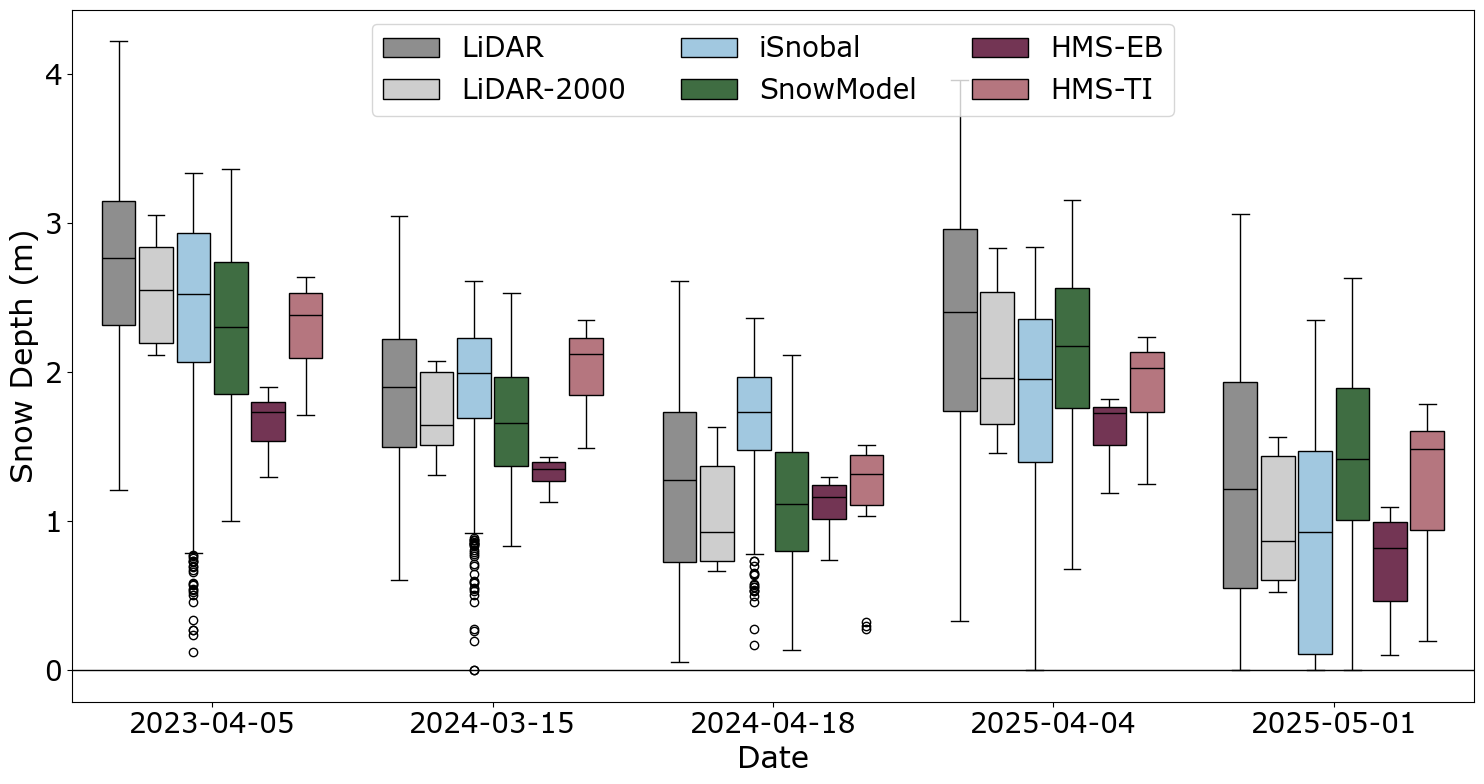

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/lidar_distributions_v2.png


In [8]:
# Make the figure and save
date_order = sorted(lidar_domain['Date'].unique())
model_order = [m for m in ['LiDAR', 'LiDAR-2000', 'iSnobal', 'SnowModel', 'HMS-EB', 'HMS-TI']
               if m in lidar_domain['Model'].unique()]
xtick_labels = [f"{d[0:4]}-{d[4:6]}-{d[6:]}" for d in date_order]

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(
    data=lidar_domain,
    x="Date", y="Snow Depth", hue="Model", palette=ds_colors_dict,
    order=date_order, hue_order=model_order, gap=0.1, ax=ax,
)

ax.set_xlabel('Date', fontsize=22)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticklabels(xtick_labels)
ax.legend(prop={'size': 20}, ncol=3, loc='upper center')
ax.axhline(0, color='k', lw=1)

plt.tight_layout()
plt.show()

fig_file = os.path.join(fig_dir, "lidar_distributions_v2.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)

# SNOTEL snow depth time series with LiDAR flight dates noted

In [9]:
# Load required input files
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS")

MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH]
)
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254  # inches -> meters

# LiDAR flight dates: which were used for data assimilation vs. held out for validation
validation_dates = pd.to_datetime(['2023-04-05', '2024-03-15', '2024-04-18', '2025-04-04', '2025-05-01'])
assimilation_dates = pd.to_datetime(['2022-12-08', '2023-02-09', '2023-03-16', '2023-12-28',
                                      '2024-01-15', '2024-02-13', '2025-01-13', '2025-01-29'])

# 30-year daily-average climatology, for context
MCS_historic = snotel_point_MCS.get_daily_data(
    datetime(1993, 10, 1), datetime(2026, 6, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH]
).reset_index(level=[1])
MCS_historic['SNOWDEPTH (m)'] = MCS_historic['SNOWDEPTH'] * 0.0254
MCS_historic.reset_index(inplace=True)
MCS_historic['datetime'] = pd.to_datetime(MCS_historic['datetime'])
MCS_historic['MM-DD'] = MCS_historic['datetime'].dt.strftime('%m-%d')
daily_avg = MCS_historic.groupby('MM-DD')['SNOWDEPTH (m)'].mean()

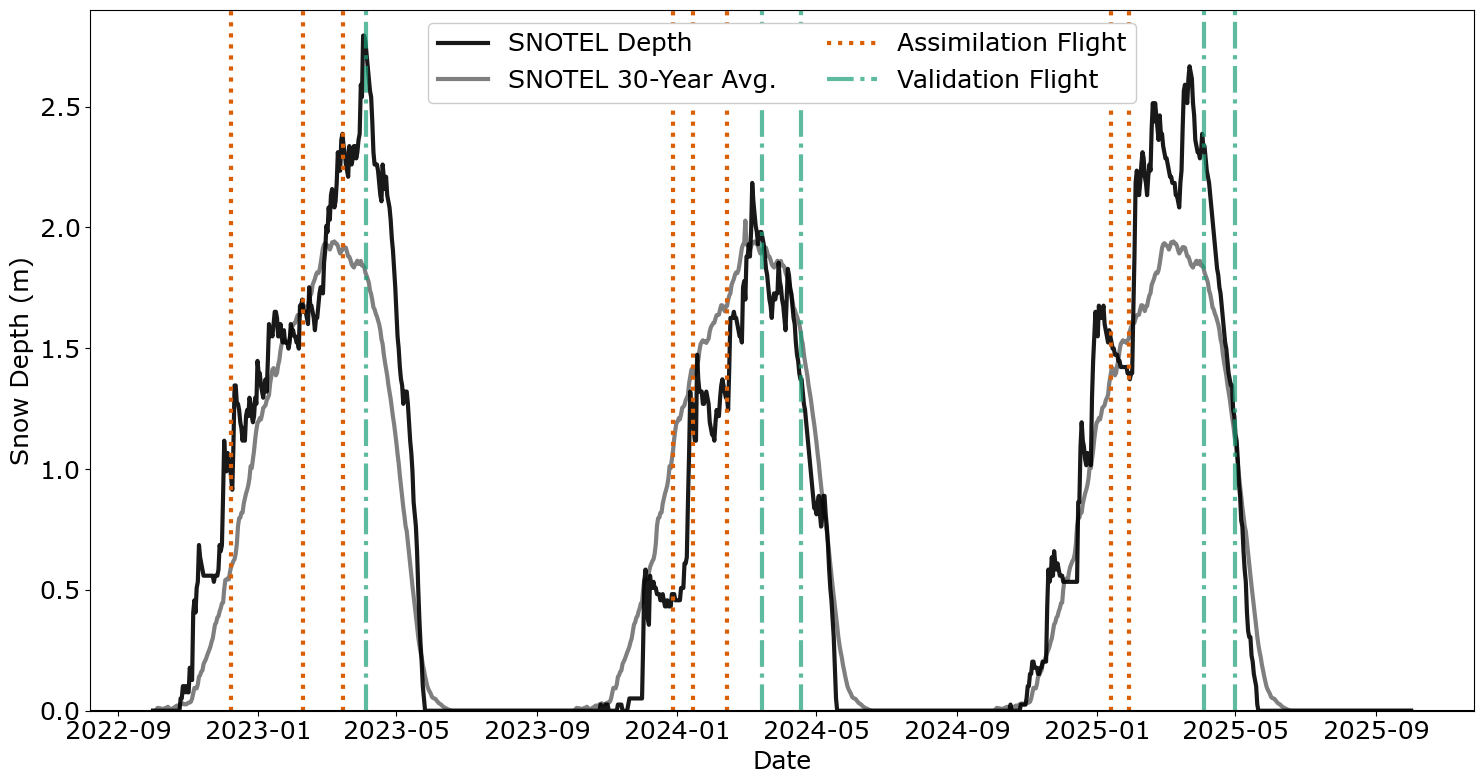

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/snotel_timeseries_v2.png


In [10]:
# Make the figure and save
dates = MCS_SNOTEL.index.get_level_values('datetime')
plot_mmdd = pd.to_datetime(dates).strftime('%m-%d')
clim_snowdepth = plot_mmdd.map(daily_avg)

lw = 3

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(dates, MCS_SNOTEL['SNOWDEPTH (m)'], linewidth=lw, label='SNOTEL Depth', alpha=0.9, color='k')
ax.plot(dates, clim_snowdepth, color='black', linestyle='-', linewidth=lw, alpha=0.5, label='SNOTEL 30-Year Avg.')

for i, d in enumerate(assimilation_dates):
    ax.axvline(x=d, color=assim_run_color, linestyle='dotted', linewidth=lw,
               label='Assimilation Flight' if i == 0 else "_nolegend_")

for i, d in enumerate(validation_dates):
    ax.axvline(x=d, color=base_run_color, linestyle='dashdot', linewidth=lw, alpha=0.7,
               label='Validation Flight' if i == 0 else "_nolegend_")

ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Snow Depth (m)', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.legend(fontsize=18, framealpha=1, facecolor='white', ncol=2, loc='upper center')
ax.axhline(0, color='k', lw=lw/2)
ax.set_ylim(0, 2.9)

plt.tight_layout()
fig_file = os.path.join(fig_dir, "snotel_timeseries_v2.png")
plt.savefig(fig_file, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", fig_file)

# Modeled vs. LiDAR snow depth scatter plots

In [11]:
# Load required input files
task1 = process_all_dates(base_dir, 1)
task2 = process_all_dates(base_dir, 2)

models = ["HMS-Energy-Balance", "HMS-Temperature-Index", "iSnobal", "SnowModel"]
date_order = sorted(task1.keys())

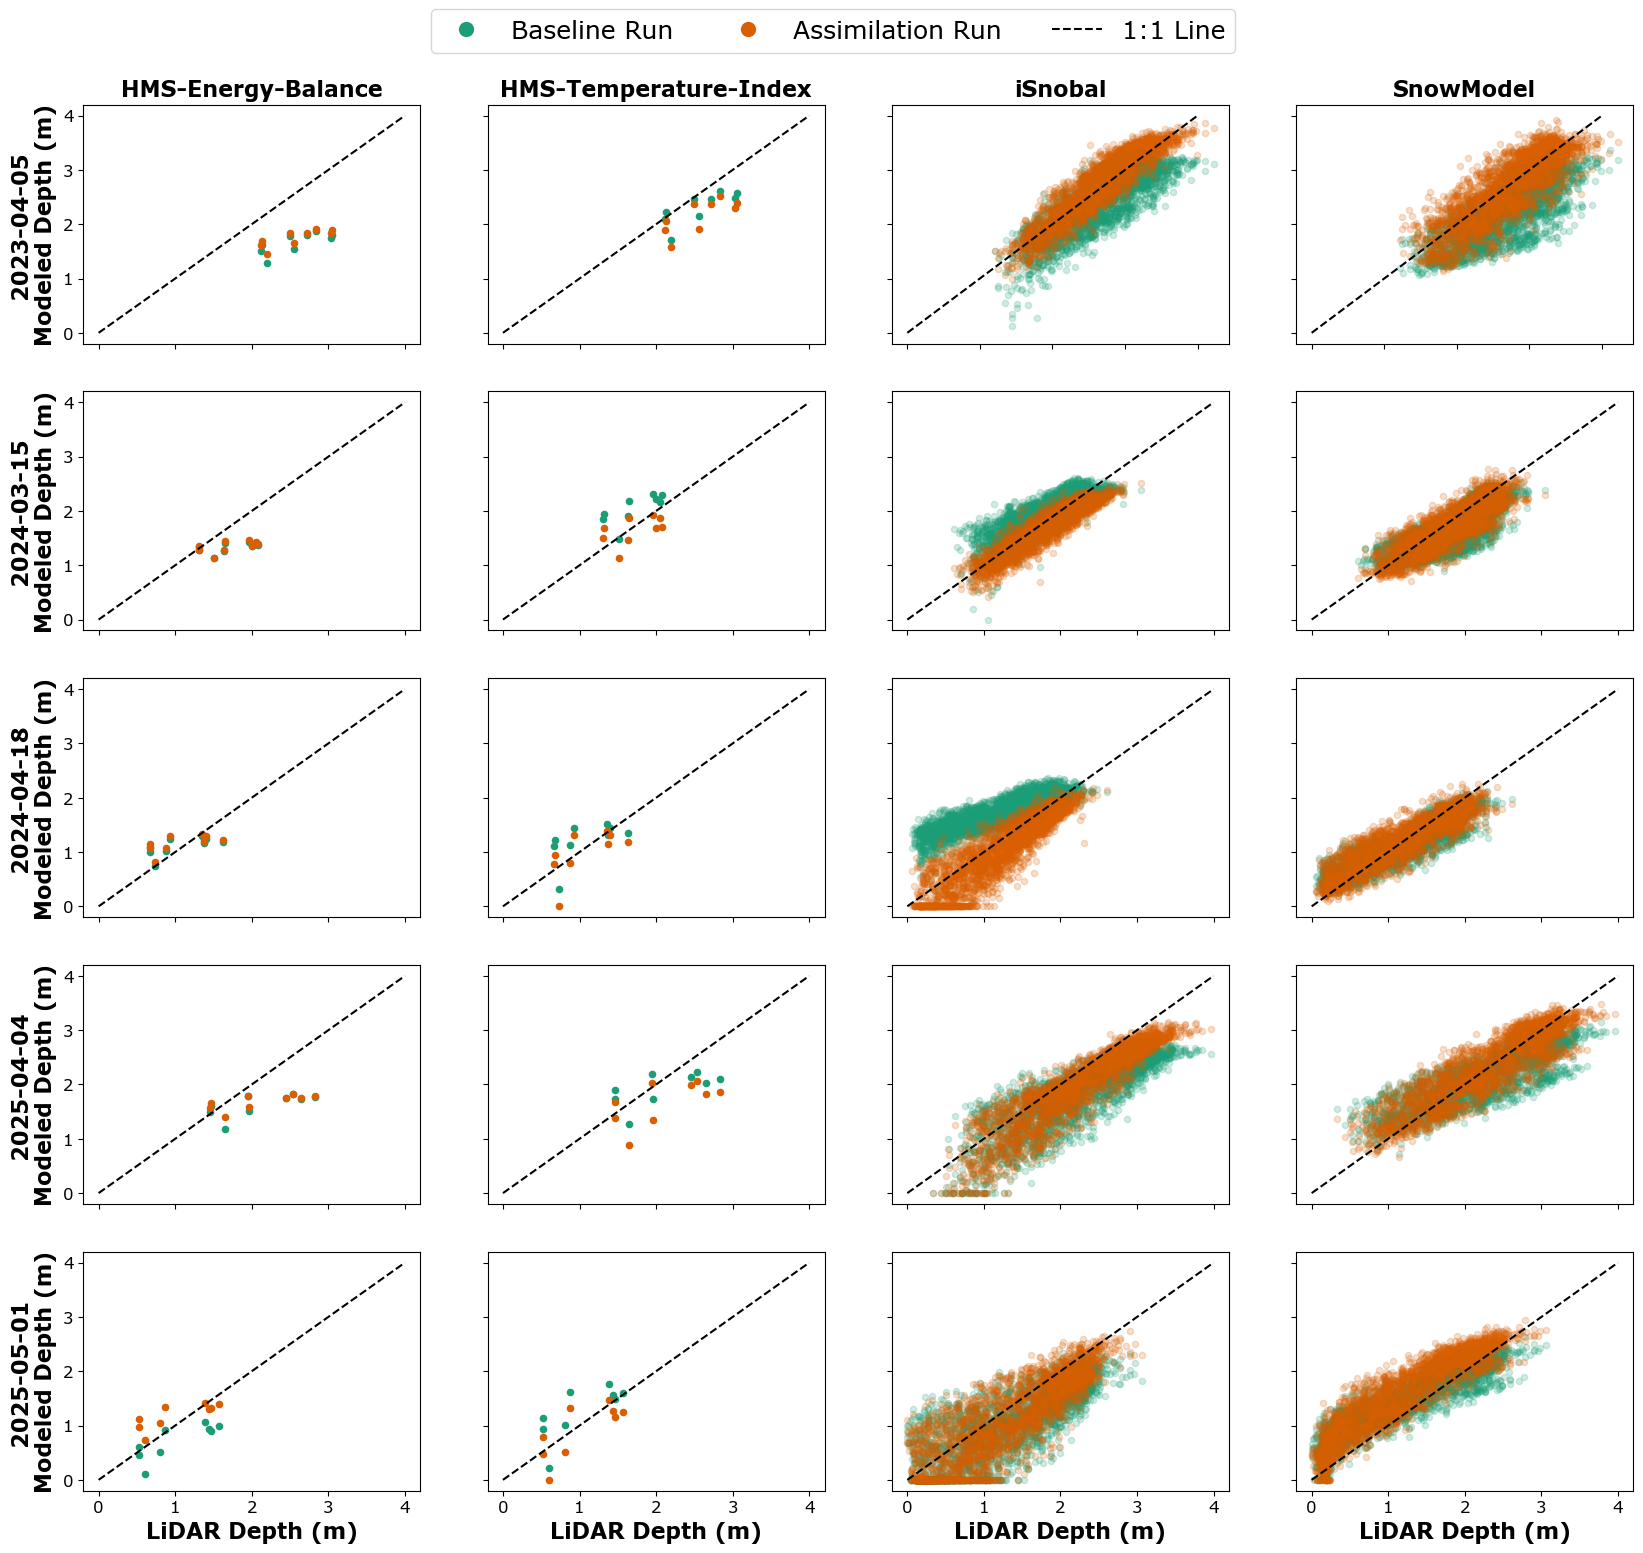

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/modeled_vs_lidar_scatter.png


In [12]:
# Make the figure and save
fig, axs = plt.subplots(nrows=len(date_order), ncols=len(models), figsize=(20, 18), sharey=True)
markersize = 20

for row, date in enumerate(date_order):
    lidar_100 = rxr.open_rasterio(task1[date]["lidar"], masked=True).squeeze()
    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(task1[date]["lidar_2000"], masked=True).squeeze()
    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    for col, model in enumerate(models):
        ax = axs[row, col]
        # ax.tick_params(axis='both', fontsize=18)

        lidar_flat = lidar_2000_flat if "HMS" in model else lidar_100_flat

        alpha = 1 if "HMS" in model else 0.2

        # Baseline
        model1 = rxr.open_rasterio(task1[date]["resample"][model], masked=True).squeeze()
        y1 = model1.values.flatten()
        mask1 = np.isfinite(lidar_flat) & np.isfinite(y1)
        sns.regplot(
            x=lidar_flat[mask1], y=y1[mask1], fit_reg=False, ax=ax, color=base_run_color, 
            scatter_kws={"s": markersize, "alpha": alpha}
            )

        # Assimilation
        model2 = rxr.open_rasterio(task2[date]["resample"][model], masked=True).squeeze()
        y2 = model2.values.flatten()
        mask2 = np.isfinite(lidar_flat) & np.isfinite(y2)
        sns.regplot(
            x=lidar_flat[mask2], y=y2[mask2], fit_reg=False, ax=ax, color=assim_run_color, 
            scatter_kws={"s": markersize, "alpha": alpha}
            )

        ax.plot([0, 4], [0, 4], color='k', linestyle='--')

        if row == len(date_order) - 1:
            ax.set_xlabel("LiDAR Depth (m)", fontweight='bold', fontsize=16)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        if row == 0:
            ax.set_title(model, fontweight='bold', fontsize=16)

        if col == 0:
            ax.set_ylabel(f"{date[0:4]}-{date[4:6]}-{date[6:]}\nModeled Depth (m)", fontweight='bold', fontsize=16)
        else:
            ax.set_ylabel("")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Baseline Run', markerfacecolor=base_run_color, markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Assimilation Run', markerfacecolor=assim_run_color, markersize=12),
    Line2D([0], [0], color='k', linestyle='--', label='1:1 Line'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.94), fontsize=18)

plt.show()

fig_file = os.path.join(fig_dir, "modeled_vs_lidar_scatter.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)

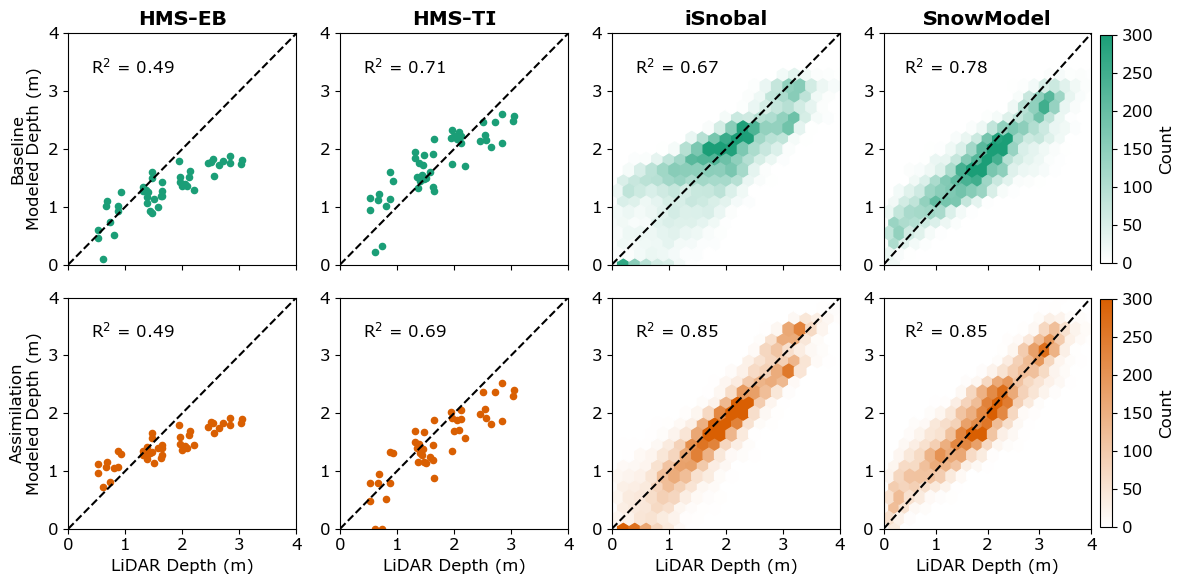

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/modeled_vs_lidar_scatter_v2.png


In [13]:
# Version 2, dates combined, hexbins for iSnobal and SnowModel
hexbin_models = {"iSnobal", "SnowModel"}
markersize = 20

task_rows = [
    ("Baseline", task1, base_run_color, base_run_cmap),
    ("Assimilation", task2, assim_run_color, assim_run_cmap),
]

fig, axs = plt.subplots(2, len(models), figsize=(12, 6))

for row, (task_label, task_dict, color, cmap) in enumerate(task_rows):
    for col, model in enumerate(models):
        ax = axs[row, col]

        # Pool all validation dates together
        x_all, y_all = [], []
        for date in date_order:
            lidar_path = task_dict[date]["lidar_2000"] if "HMS" in model else task_dict[date]["lidar"]
            lidar_flat = rxr.open_rasterio(lidar_path, masked=True).squeeze()
            lidar_flat = lidar_flat.where(lidar_flat < 5).values.flatten()

            modeled_flat = rxr.open_rasterio(task_dict[date]["resample"][model], masked=True).squeeze()
            modeled_flat = modeled_flat.values.flatten()

            mask = np.isfinite(lidar_flat) & np.isfinite(modeled_flat)
            x_all.append(lidar_flat[mask])
            y_all.append(modeled_flat[mask])

        x_all = np.concatenate(x_all)
        y_all = np.concatenate(y_all)

        if model in hexbin_models:
            hb = ax.hexbin(x_all, y_all, gridsize=20, cmap=cmap, mincnt=1, extent=(0, 4, 0, 4), clim=(0,300))
            if col==3:  
                fig.colorbar(hb, ax=ax, fraction=0.05, pad=0.04, label="Count")
        else:
            ax.scatter(x_all, y_all, s=markersize, alpha=1, color=color)

        ax.plot([0, 4], [0, 4], color='k', linestyle='--')
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)

        if row == 1:
            ax.set_xlabel("LiDAR Depth (m)")#, fontweight='bold')
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        if row == 0:
            if "Energy" in model:
                model_name = "HMS-EB"
            elif "Temp" in model:
                model_name = "HMS-TI"
            else:
                model_name = model
            ax.set_title(model_name, fontweight='bold')

        if col == 0:
            ax.set_ylabel(f"{task_label}\nModeled Depth (m)")
        else:
            ax.set_ylabel("")

        # Add R2 annotation
        ss_res = np.sum((x_all - y_all) ** 2)
        ss_tot = np.sum((x_all - np.mean(y_all)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        ax.text(0.1, 0.9, f"R$^2$ = {r2:.2}", transform=ax.transAxes, va='top', ha='left')

# legend_elements = [Line2D([0], [0], color='k', linestyle='--', label='1:1 Line')]
# fig.legend(handles=legend_elements, loc='lower center', ncol=1, bbox_to_anchor=(0.5, 0.95))

fig.tight_layout()
plt.show()

fig_file = os.path.join(fig_dir, "modeled_vs_lidar_scatter_v2.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)

# R^2 per LiDAR validation date, per model

In [50]:
# Load required input files
task1 = process_all_dates(base_dir, 1)
task2 = process_all_dates(base_dir, 2)

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

regressions = []
for date in task1.keys():
    lidar_100 = rxr.open_rasterio(task1[date]['lidar'], masked=True).squeeze()
    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(task1[date]['lidar_2000'], masked=True).squeeze()
    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    resample_tasks = {"Task 1": task1[date]['resample'], "Task 2": task2[date]['resample']}

    for task_name, resampled_models in resample_tasks.items():
        for model_name, model_path in resampled_models.items():
            modeled = rxr.open_rasterio(model_path, masked=True).squeeze()
            modeled_flat = modeled.values.flatten()

            lidar_flat = lidar_2000_flat if "HMS" in model_name else lidar_100_flat

            mask = ~np.isnan(lidar_flat) & ~np.isnan(modeled_flat)
            x_clean = lidar_flat[mask]
            y_clean = modeled_flat[mask]

            if "Temperature" in model_name:
                model_name_save = "HMS-TI"
            elif "Energy" in model_name:
                model_name_save = "HMS-EB"
            else:
                model_name_save = model_name

            if len(x_clean) > 1 and len(y_clean) > 1:
                reg = linregress(x_clean, y_clean)
                regressions.append({
                    "Task": task_name,
                    "Condition": "Assimilation" if task_name == "Task 2" else "Baseline",
                    "Date": date,
                    "Model": model_name_save,
                    "slope": reg.slope,
                    "intercept": reg.intercept,
                    "rvalue": reg.rvalue,
                    "pvalue": reg.pvalue,
                    "stderr": reg.stderr,
                    "RMSE": rmse_numpy(x_clean, y_clean),
                })

regression_df = pd.DataFrame(regressions)
regression_df['r-squared'] = regression_df['rvalue'] ** 2

# Restructure to match the format in the paper
regression_df['Date'] = pd.to_datetime(regression_df['Date'], format='%Y%m%d').dt.strftime('%Y-%m-%d')
pivoted = regression_df.pivot(
    index=['Date', 'Model'], 
    columns='Condition', 
    values=['r-squared', 'RMSE', 'pvalue']
)
pivoted = pivoted.swaplevel(axis=1)
pivoted = pivoted[['Baseline', 'Assimilation']]
pivoted = pivoted.reindex(['r-squared', 'RMSE', 'pvalue'], level=1, axis=1)

regression_file = os.path.join(fig_dir, "regression_results.csv")
pivoted.to_csv(regression_file, index=True)
print("Saved regression parameters to:", regression_file)
pivoted.round(2)

Saved regression parameters to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/regression_results.csv


Condition             Baseline              Assimilation             
                     r-squared  RMSE pvalue    r-squared  RMSE pvalue
Date       Model                                                     
2023-04-05 HMS-EB         0.54  0.94   0.02         0.62  0.86   0.01
           HMS-TI         0.59  0.35   0.02         0.54  0.48   0.02
           SnowModel      0.62  0.56   0.00         0.69  0.34   0.00
           iSnobal        0.70  0.39   0.00         0.86  0.24   0.00
2024-03-15 HMS-EB         0.28  0.47   0.14         0.32  0.45   0.11
           HMS-TI         0.53  0.38   0.03         0.28  0.27   0.14
           SnowModel      0.64  0.32   0.00         0.73  0.25   0.00
           iSnobal        0.69  0.28   0.00         0.86  0.21   0.00
2024-04-18 HMS-EB         0.41  0.28   0.06         0.39  0.29   0.07
           HMS-TI         0.31  0.35   0.12         0.40  0.34   0.07
           SnowModel      0.80  0.28   0.00         0.80  0.26   0.00
           iSnobal        0.75  0.63   0.00         0.82  0.32   0.00
2025-04-04 HMS-EB         0.44  0.62   0.05         0.50  0.59   0.03
           HMS-TI         0.40  0.43   0.07         0.39  0.58   0.07
           SnowModel      0.73  0.42   0.00         0.82  0.31   0.00
           iSnobal        0.75  0.57   0.00         0.86  0.39   0.00
2025-05-01 HMS-EB         0.65  0.39   0.01         0.62  0.32   0.01
           HMS-TI         0.53  0.40   0.03         0.58  0.33   0.02
           SnowModel      0.84  0.38   0.00         0.86  0.46   0.00
           iSnobal        0.68  0.53   0.00         0.75  0.44   0.00

In [51]:
# Print in LaTeX form for the paper
print(pivoted.round(2).loc[:, [
    ('Baseline', 'r-squared'), ('Baseline', 'RMSE'), ('Baseline', 'pvalue'),
    ('Assimilation', 'r-squared'), ('Assimilation', 'RMSE'), ('Assimilation', 'pvalue')
    ]].to_latex())

\begin{tabular}{llrrrrrr}
\toprule
 & Condition & \multicolumn{3}{r}{Baseline} & \multicolumn{3}{r}{Assimilation} \\
 &  & r-squared & RMSE & pvalue & r-squared & RMSE & pvalue \\
Date & Model &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{2023-04-05} & HMS-EB & 0.540000 & 0.940000 & 0.020000 & 0.620000 & 0.860000 & 0.010000 \\
 & HMS-TI & 0.590000 & 0.350000 & 0.020000 & 0.540000 & 0.480000 & 0.020000 \\
 & SnowModel & 0.620000 & 0.560000 & 0.000000 & 0.690000 & 0.340000 & 0.000000 \\
 & iSnobal & 0.700000 & 0.390000 & 0.000000 & 0.860000 & 0.240000 & 0.000000 \\
\cline{1-8}
\multirow[t]{4}{*}{2024-03-15} & HMS-EB & 0.280000 & 0.470000 & 0.140000 & 0.320000 & 0.450000 & 0.110000 \\
 & HMS-TI & 0.530000 & 0.380000 & 0.030000 & 0.280000 & 0.270000 & 0.140000 \\
 & SnowModel & 0.640000 & 0.320000 & 0.000000 & 0.730000 & 0.250000 & 0.000000 \\
 & iSnobal & 0.690000 & 0.280000 & 0.000000 & 0.860000 & 0.210000 & 0.000000 \\
\cline{1-8}
\multirow[t]{4}{*}{2024-04-18} & HMS-EB & 0.410000 & 

/var/folders/46/lc6lgy656cq4n776s7js9r880000gr/T/ipykernel_39684/2626451732.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(xtick_labels)
/var/folders/46/lc6lgy656cq4n776s7js9r880000gr/T/ipykernel_39684/2626451732.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(xtick_labels)


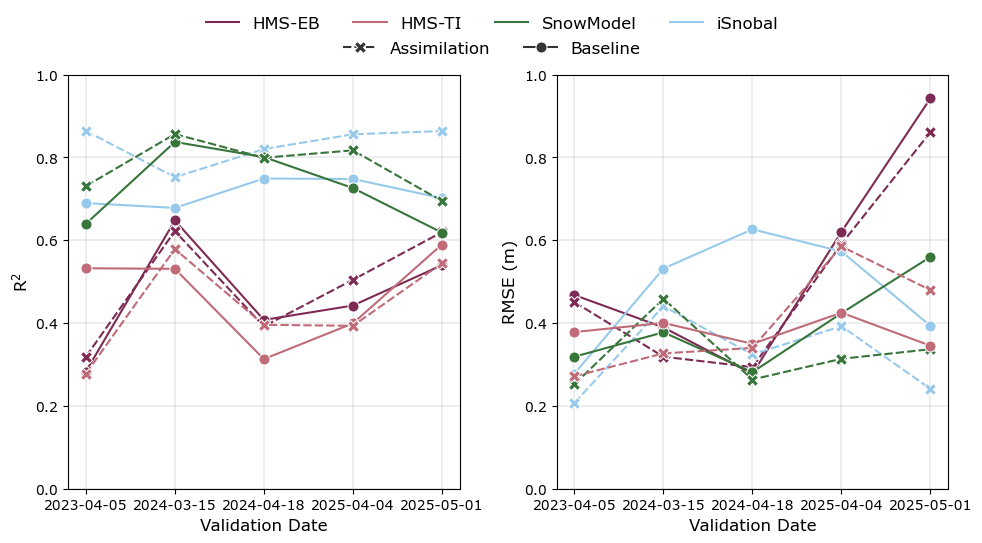

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/r2_rmse_v2.png


In [66]:
date_order = sorted(regression_df['Date'].unique())
xtick_labels = date_order

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# R-squared
sns.lineplot(
    ax=ax[0],
    data=regression_df,
    x='Date',
    y='r-squared',
    hue='Model',
    palette=ds_colors_dict,
    style='Condition',
    markers=True,
    markersize=8
)
ax[0].set_xticklabels(xtick_labels)
ax[0].set_xlabel("Validation Date")
ax[0].set_ylabel("R$^2$")

# RMSE
sns.lineplot(
    ax=ax[1],
    data=regression_df,
    x='Date',
    y='RMSE',
    hue='Model',
    palette=ds_colors_dict,
    style='Condition',
    markers=True, 
    markersize=8
)
ax[1].set_xticklabels(xtick_labels)
ax[1].set_xlabel("Validation Date")
ax[1].set_ylabel("RMSE (m)")
ax[1].get_legend().remove()

handles, labels = ax[0].get_legend_handles_labels()
isort = np.argsort(labels)
handles = [handles[i] for i in isort if labels[i]!="Model" and labels[i]!="Condition"]
labels = [labels[i] for i in isort if labels[i]!="Model" and labels[i]!="Condition"]
ax[0].legend().remove()
fig.legend(handles[2:], labels[2:], loc='upper center', frameon=False, ncol=4, bbox_to_anchor=[0.4, 0.9, 0.2, 0.2])
fig.legend(handles[0:2], labels[0:2], loc='upper center', frameon=False, ncol=2, bbox_to_anchor=[0.4, 0.85, 0.2, 0.2])

for axis in ax:
    axis.set_ylim(0,1)
    axis.grid(which='both', color='k', alpha=0.5, lw=0.2)
    axis.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()

plt.show()

fig_file = os.path.join(fig_dir, "r2_rmse_v2.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)


In [ ]:
# Try running with the more clipped HMS domain to see if that's the difference from Nani's original run


# SNOTEL time series and LiDAR

In [16]:
# --- Load (or build & cache) daily modeled + observed snow depth at each SNOTEL station ---
model_outputs_dir = "/Users/rdcrlrka/Research/SIRO/MCSModeling/SIRO_P1/ModelOutputs"
station_list = [
    ("637", "Mores Creek Summit"),
    ("978", "Bogus Basin"),
]
INCHES_TO_M = 0.0254
task_labels = {1: "Baseline", 2: "Assimilation"}

def build_daily_samples(station_id, station_name):
    pt = SnotelPointData(f"{station_id}:ID:SNTL", station_name)
    sx, sy = x_y_snotel(pt)
    records = []  # (date, model, task, snow_depth_m)

    def sample_tif(path, scale=1.0):
        with rasterio.open(path) as src:
            row, col = src.index(sx, sy)
            val = src.read(1, window=((row, row + 1), (col, col + 1)))[0, 0]
            return np.nan if val == src.nodata else val * scale

    # --- SNOTEL (observed, inches) ---
    SNOTEL = pt.get_daily_data(
        datetime(2022, 10, 1), datetime(2025, 10, 1), [pt.ALLOWED_VARIABLES.SNOWDEPTH]
    )
    snotel_series = SNOTEL['SNOWDEPTH'].reset_index(level='site', drop=True) * INCHES_TO_M
    # metloom returns tz-aware 08:00 UTC stamps; strip so dates line up with the model dates
    snotel_series.index = pd.to_datetime(snotel_series.index).tz_localize(None).normalize()
    for date, val in snotel_series.items():
        records.append((date, "SNOTEL", "Observed", val))

    # --- HMS (daily geotiffs, inches) ---
    hms_daily_dirs = {
        ("HMS-EB", 1): os.path.join(model_outputs_dir, "HMS_Task1", "EB", "snow_depth_tif"),
        ("HMS-EB", 2): os.path.join(model_outputs_dir, "HMS_Task2", "EB", "snow_depth_tif"),
        ("HMS-TI", 1): os.path.join(model_outputs_dir, "HMS_Task1", "TI", "snow_depth_tif"),
        ("HMS-TI", 2): os.path.join(model_outputs_dir, "HMS_Task2", "TI", "snow_depth_tif"),
    }
    hms_date_pattern = re.compile(r"(\d{4}_\d{2}_\d{2})T0000")
    for (model_name, task), tif_dir in hms_daily_dirs.items():
        for path in sorted(glob(os.path.join(tif_dir, "*.tif*"))):
            m = hms_date_pattern.search(os.path.basename(path))
            if m:
                date = pd.to_datetime(m.group(1), format="%Y_%m_%d")
                records.append((date, model_name, task_labels[task], sample_tif(path, INCHES_TO_M)))

    # --- iSnobal (daily geotiffs, meters) ---
    isnobal_dirs = {
        1: os.path.join(model_outputs_dir, "m3w_isnobal_task1", "m3w_isnobal_task1_depth"),
        2: os.path.join(model_outputs_dir, "m3w_isnobal_task_2_all_updated", "m3w_isnobal_task2_depth"),
    }
    isnobal_date_pattern = re.compile(r"depth_(\d{4}-\d{2}-\d{2})T")
    for task, base in isnobal_dirs.items():
        for path in sorted(glob(os.path.join(base, "wy*", "*.tif"))):
            m = isnobal_date_pattern.search(os.path.basename(path))
            if m:
                date = pd.to_datetime(m.group(1), format="%Y-%m-%d")
                records.append((date, "iSnobal", task_labels[task], sample_tif(path)))

    # --- SnowModel (netCDF per water year, meters) ---
    for task in (1, 2):
        for nc_path in sorted(glob(os.path.join(model_outputs_dir, "SnowModel", f"SnowModel_WY*_Task{task}.nc"))):
            with xr.open_dataset(nc_path) as ds:
                series = ds["SD"].sel(x=sx, y=sy, method="nearest").to_series()
            for date, val in series.items():
                records.append((pd.Timestamp(date).normalize(), "SnowModel", task_labels[task], val))

    df = pd.DataFrame.from_records(records, columns=["date", "model", "task", "snow_depth_m"])
    # unstack (unlike pivot_table) raises on duplicate dates instead of silently averaging them
    return df.set_index(["date", "model", "task"])["snow_depth_m"].unstack(["model", "task"])


snotel_dict = {}
for station_id, station_name in station_list:
    csv_path = os.path.join(fig_dir, f"SNOTEL_model_daily_samples_{station_name.replace(' ', '')}.csv")
    if os.path.exists(csv_path):
        print(f"Daily SNOTEL samples already exist for {station_name}, loading.")
        df = pd.read_csv(csv_path, header=[0, 1], index_col=0, parse_dates=True)
    else:
        print(f"Building daily samples for {station_name}...")
        df = build_daily_samples(station_id, station_name)
        df.to_csv(csv_path)
        print(f"Saved {len(df)} days to {csv_path}")
    df.dropna(inplace=True)
    snotel_dict[station_name] = {"df": df}

snotel_dict["Mores Creek Summit"]["df"].head()

Daily SNOTEL samples already exist for Mores Creek Summit, loading.
Daily SNOTEL samples already exist for Bogus Basin, loading.


model        SNOTEL   HMS-EB                HMS-TI               iSnobal  \
task       Observed Baseline Assimilation Baseline Assimilation Baseline   
date                                                                       
2022-10-02      0.0      0.0          0.0      0.0          0.0      0.0   
2022-10-03      0.0      0.0          0.0      0.0          0.0      0.0   
2022-10-04      0.0      0.0          0.0      0.0          0.0      0.0   
2022-10-05      0.0      0.0          0.0      0.0          0.0      0.0   
2022-10-06      0.0      0.0          0.0      0.0          0.0      0.0   

model                   SnowModel               
task       Assimilation  Baseline Assimilation  
date                                            
2022-10-02          0.0       0.0          0.0  
2022-10-03          0.0       0.0          0.0  
2022-10-04          0.0       0.0          0.0  
2022-10-05          0.0       0.0          0.0  
2022-10-06          0.0       0.0          0.0

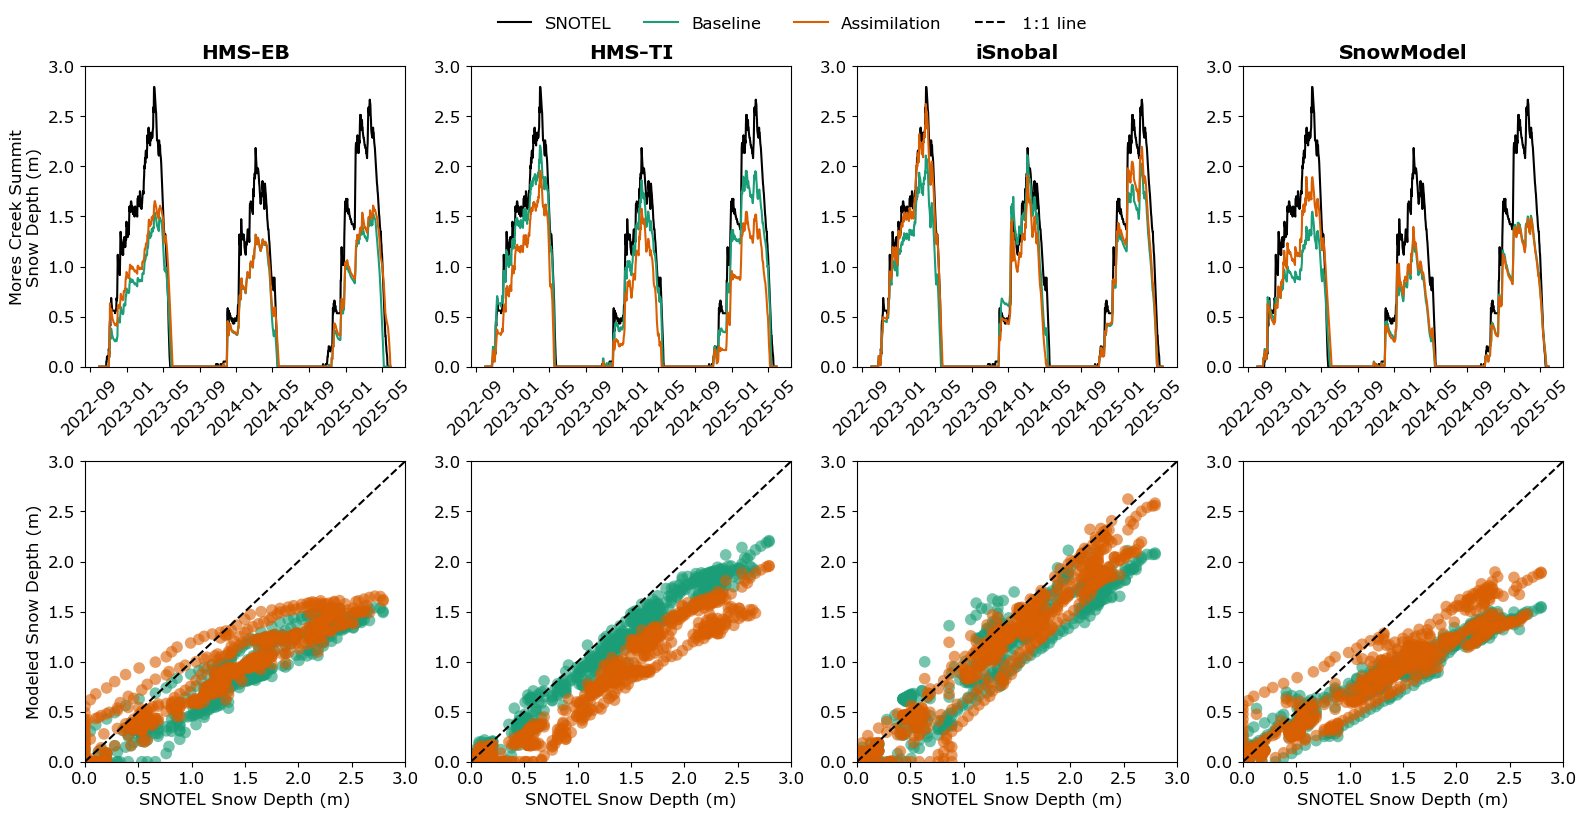

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/SNOTEL_timeseries_scatter_Mores_Creek_Summit_v2.png


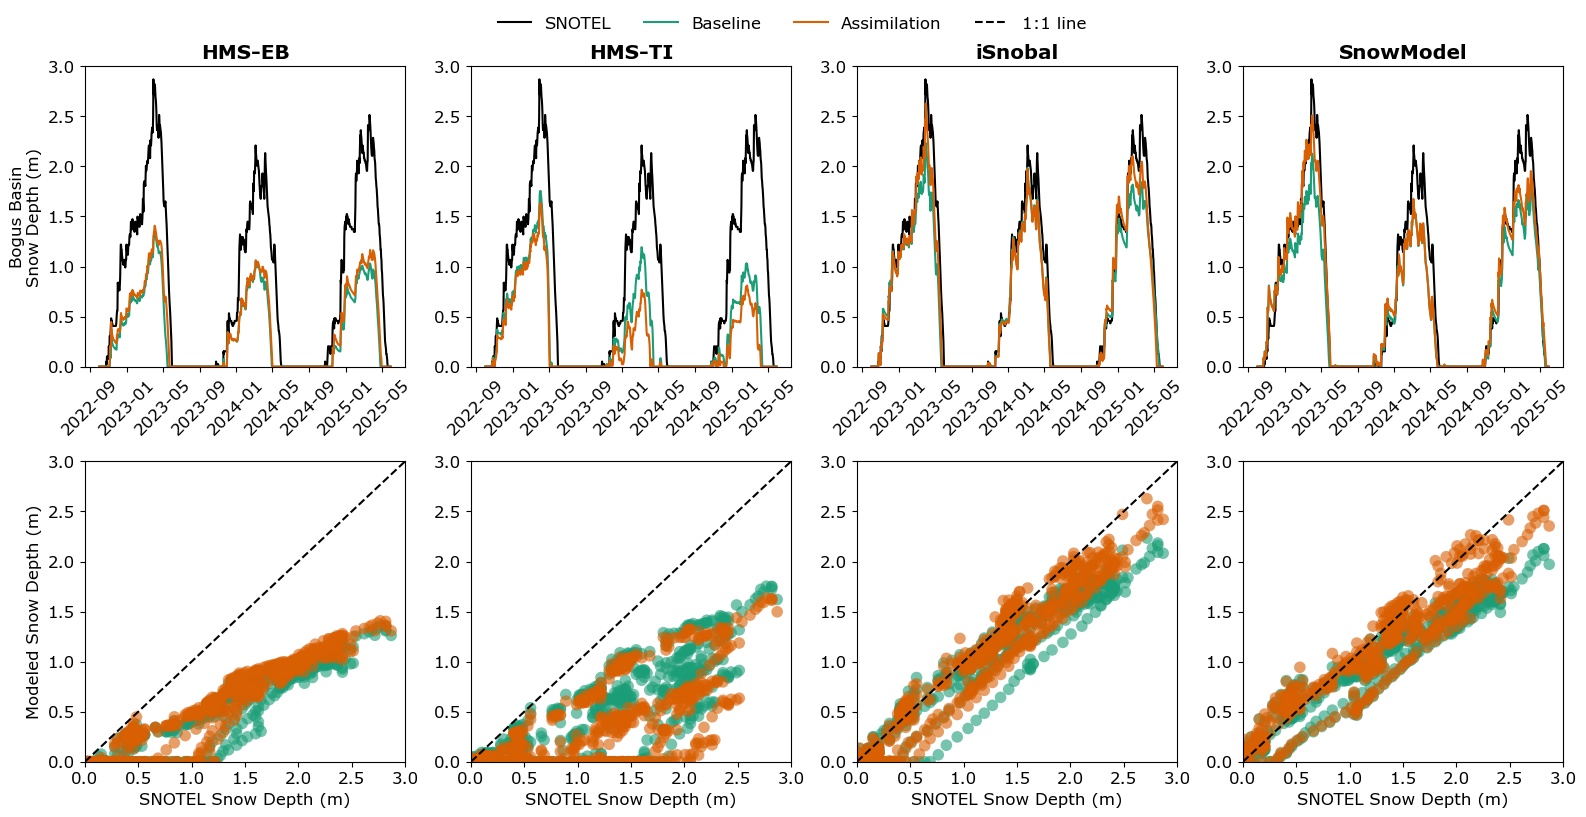

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCSModeling/figures/SNOTEL_timeseries_scatter_Bogus_Basin_v2.png


In [17]:
# SNOTEL vs. modeled snow depth: one figure per station.
plot_models = ["HMS-EB", "HMS-TI", "iSnobal", "SnowModel"]
run_styles = [("Baseline", base_run_color), ("Assimilation", assim_run_color)]
lim = (0, 3)
lw = 1.5
ms = 70

for station_name, station_data in snotel_dict.items():
    df = station_data["df"]
    obs = df[("SNOTEL", "Observed")].dropna()

    fig, axs = plt.subplots(2, len(plot_models), figsize=(16,8))

    for col, model in enumerate(plot_models):
        ax_ts, ax_sc = axs[0, col], axs[1, col]

        # --- Row 1: time series ---
        ax_ts.plot(obs.index, obs.values, color='k', linewidth=lw)
        for run, color in run_styles:
            ax_ts.plot(df.index, df[(model, run)], color=color, linewidth=lw)
        ax_ts.set_title(model, fontweight='bold')
        ax_ts.tick_params(axis='x', rotation=45)#, labelsize=9)
        ax_ts.set_ylim(lim)
        if col == 0:
            ax_ts.set_ylabel(f"{station_name}\nSnow Depth (m)")

        # --- Row 2: SNOTEL vs. modeled, every date where both exist ---
        for k, (run, color) in enumerate(run_styles):
            pair = pd.concat([obs, df[(model, run)]], axis=1, keys=["obs", "mod"]).dropna()
            ax_sc.scatter(pair["obs"], pair["mod"], s=ms, alpha=0.6, color=color, edgecolor='none')

        ax_sc.plot(lim, lim, color='k', linestyle='--', linewidth=lw)
        ax_sc.set_xlim(lim)
        ax_sc.set_ylim(lim)
        ax_sc.set_xlabel("SNOTEL Snow Depth (m)")
        if col == 0:
            ax_sc.set_ylabel("Modeled Snow Depth (m)")

    legend_handles = [
        Line2D([0], [0], color='k', linewidth=lw, label='SNOTEL'),
        Line2D([0], [0], color=base_run_color, linewidth=lw, label='Baseline'),
        Line2D([0], [0], color=assim_run_color, linewidth=lw, label='Assimilation'),
        Line2D([0], [0], color='k', linestyle='--', linewidth=lw, label='1:1 line'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.tight_layout()
    plt.show()

    fig_file = os.path.join(fig_dir, f"SNOTEL_timeseries_scatter_{station_name.replace(' ', '_')}_v2.png")
    fig.savefig(fig_file, dpi=300, bbox_inches='tight')
    print("Figure saved to:", fig_file)